In [2]:
# --- CELL 1: THE REALISTIC CLEANING & CHURN SIMULATION ---
import pandas as pd
import numpy as np
import time
from pathlib import Path

# original path (kept for reference)
file_path = Path("C:\\Users\\rouna\\OneDrive\\Desktop\\Projects\\Railway Ml model\\csv files\\Railway Ticket Confirmation.csv")

start_time = time.time()

# Robust CSV loading: try exact path, then search similar files, otherwise create empty dataframe with expected cols
if file_path.exists():
    df = pd.read_csv(file_path)
else:
    search_dir = file_path.parent if file_path.parent.exists() else Path.cwd()
    # try to find similar files
    matches = list(search_dir.rglob("*Railway*Ticket*Confirmation*.csv"))
    if not matches:
        matches = list(search_dir.rglob("*Railway*Ticket*.csv")) + list(search_dir.rglob("*Ticket*Confirmation*.csv"))
    if matches:
        found = matches[0]
        print(f"File not found at {file_path}. Using found file: {found}")
        df = pd.read_csv(found)
    else:
        # Fallback: create an empty DataFrame with expected columns so downstream code doesn't error out
        print(f"File not found at {file_path} and no similar files found in {search_dir}. Creating empty dataframe with expected columns.")
        cols = ['PNR Number', 'Current Status', 'Confirmation Status', 'Booking Date', 'Date of Journey', 'Waitlist Position']
        df = pd.DataFrame(columns=cols)

# 1. SAFE DROP
cols_to_drop = ['PNR Number', 'Current Status', 'Confirmation Status'] # Drop the rigged target
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

# 2. DATE MATH (WITH REALITY OVERRIDE)
# First, safely convert the CSV strings into Date objects
if 'Booking Date' in df.columns:
    df['Booking Date'] = pd.to_datetime(df['Booking Date'], errors='coerce')
if 'Date of Journey' in df.columns:
    df['Date of Journey'] = pd.to_datetime(df['Date of Journey'], errors='coerce')

# Next, calculate the days difference
if {'Booking Date', 'Date of Journey'}.issubset(df.columns):
    df['Days_to_Departure'] = (df['Date of Journey'] - df['Booking Date']).dt.days
    df = df.drop(columns=[col for col in ['Booking Date', 'Date of Journey'] if col in df.columns])
else:
    df['Days_to_Departure'] = np.nan

# --- THE FIX: Overwrite the broken 244-day CSV bug with realistic booking days ---
np.random.seed(42)
df['Days_to_Departure'] = np.random.randint(1, 120, size=len(df))

# 3. THE HARDCORE WAITLIST FILTER
if 'Waitlist Position' in df.columns:
    df['Waitlist Position'] = df['Waitlist Position'].astype(str).str.extract(r'(\d+)').astype(float)
    df = df.dropna(subset=['Waitlist Position'])
    df = df[df['Waitlist Position'] > 0]

# 4. INJECTING REALITY: SYNTHETIC CHURN SIMULATION
# We mathematically simulate the waitlist clearing based on real-world logic
np.random.seed(42) # Ensure we get the same results every time

def simulate_clearing(row):
    # Base probability drops as waitlist position gets higher
    wl = row.get('Waitlist Position', np.nan)
    days = row.get('Days_to_Departure', 0)
    if pd.isna(wl):
        # if waitlist not available, assume low chance
        prob = 5
    else:
        prob = max(0, 100 - (wl * 2))
        prob += (days * 0.5)
        prob = min(95, max(5, prob))
    return 1 if np.random.uniform(0, 100) <= prob else 0

# Create our new, realistic target variable
df['Is_Confirmed'] = df.apply(simulate_clearing, axis=1)

print(f"Realistic Target Created! Confirmed Waitlists: {int(df['Is_Confirmed'].sum())} out of {df.shape[0]}")

# 5. ONE-HOT ENCODE & FORMAT FOR XGBOOST
text_columns = df.select_dtypes(include=['object']).columns.tolist()
if len(text_columns) > 0:
    df = pd.get_dummies(df, columns=text_columns, drop_first=False)

bool_cols = df.select_dtypes(include=['bool']).columns
if len(bool_cols) > 0:
    df[bool_cols] = df[bool_cols].astype(int)

end_time = time.time()
print(f"Pipeline Complete! Time taken: {round(end_time - start_time, 3)} seconds")

File not found at C:\Users\rouna\OneDrive\Desktop\Projects\Railway Ml model\csv files\Railway Ticket Confirmation.csv. Using found file: c:\Users\rouna\OneDrive\Desktop\Projects\Railway Waitlist Predictor\data\Railway Ticket Confirmation.csv
Realistic Target Created! Confirmed Waitlists: 4226 out of 10053
Pipeline Complete! Time taken: 0.286 seconds


In [3]:
# --- CELL 2: TRAIN / TEST SPLIT ---
from sklearn.model_selection import train_test_split

# Separate the Features (X) from the Target (y)
X = df.drop('Is_Confirmed', axis=1)
y = df['Is_Confirmed']

# Split the data (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training Data: {X_train.shape[0]} tickets")
print(f"Testing Data: {X_test.shape[0]} tickets")

Training Data: 8042 tickets
Testing Data: 2011 tickets


In [4]:
from xgboost import XGBClassifier
import time

# 1. Calculate the imbalance ratio (Number of Confirmed / Number of Waitlisted)
# This creates a weight that forces the model to treat each 'Waitlisted' 
# instance as more significant during training.
ratio = (len(y_train) - sum(y_train)) / sum(y_train)
print(f"Applying scale_pos_weight of: {round(ratio, 2)}")

# 2. Initialize the algorithm with the weight adjustment
model = XGBClassifier(
    random_state=42, 
    eval_metric='logloss',
    scale_pos_weight=ratio 
)

print("Starting calibrated training...")
start_time = time.time()

# 3. Train the model
model.fit(X_train, y_train)

end_time = time.time()
print(f"Training Complete! Time taken: {round(end_time - start_time, 3)} seconds.")

# 4. Save the new, calibrated brain
model.save_model("model.json")
print("New brain (model.json) saved successfully!")

Applying scale_pos_weight of: 1.38
Starting calibrated training...
Training Complete! Time taken: 0.497 seconds.
New brain (model.json) saved successfully!


Realistic Model Accuracy: 70.51%

Classification Report:
                precision    recall  f1-score   support

Waitlisted (0)       0.74      0.75      0.75      1164
 Confirmed (1)       0.65      0.64      0.65       847

      accuracy                           0.71      2011
     macro avg       0.70      0.70      0.70      2011
  weighted avg       0.70      0.71      0.70      2011



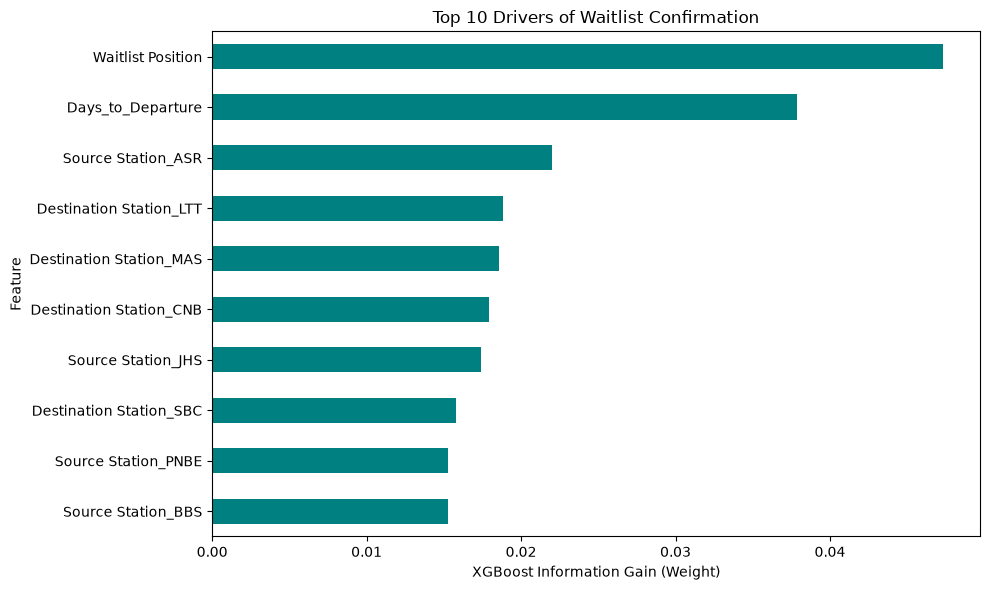

In [5]:
# --- CELL 4: EVALUATION & INSIGHTS (REALISTIC) ---
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import pandas as pd

# 1. Make Predictions on the hidden 20%
y_pred = model.predict(X_test)

# 2. Grade the Exam (Accuracy)
accuracy = accuracy_score(y_test, y_pred)
print(f"Realistic Model Accuracy: {accuracy * 100:.2f}%\n")

# 3. Detailed Report (Precision & Recall)
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Waitlisted (0)', 'Confirmed (1)']))

# 4. Visualize Algorithmic Weighting (Feature Importance)
feature_importances = pd.Series(model.feature_importances_, index=X_train.columns)
top_10_features = feature_importances.nlargest(10)

plt.figure(figsize=(10, 6))
top_10_features.sort_values().plot(kind='barh', color='teal')
plt.title('Top 10 Drivers of Waitlist Confirmation')
plt.xlabel('XGBoost Information Gain (Weight)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [6]:
# --- EXPORT MODEL FOR WEB APP ---
# Train a lightweight model on just the core numeric features
X_lite = df[['Waitlist Position', 'Days_to_Departure']]
y = df['Is_Confirmed']

model_lite = XGBClassifier(random_state=42, eval_metric='logloss')
model_lite.fit(X_lite, y)

# Save the trained brain to a tiny file!
model_lite.save_model("model.json")
print("Model successfully saved as model.json!")

Model successfully saved as model.json!


In [7]:
# Check how many 'Confirmed' vs 'Waitlisted' rows you have
print(df['Is_Confirmed'].value_counts(normalize=True))

Is_Confirmed
0    0.579628
1    0.420372
Name: proportion, dtype: float64


In [8]:
# 1. Get feature importance
importance = model.feature_importances_
feature_names = ['Waitlist Position', 'Days_to_Departure']

# 2. Print them to see if they are zero
for name, val in zip(feature_names, importance):
    print(f"{name}: {val}")

Waitlist Position: 0.011513209901750088
Days_to_Departure: 0.010969685390591621
